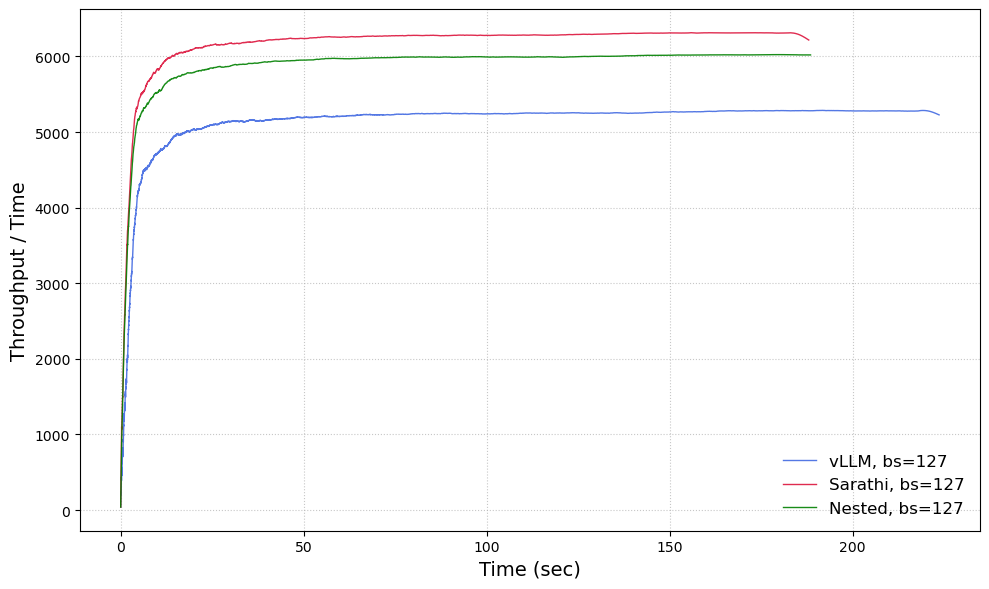

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
vllm_df = pd.read_csv('./vllm/throughput_vllm_batch_size_127.csv')
booking_df = pd.read_csv('./modified_nested/throughput_general_nested_booking_limit_limit_128_batch_size_127.csv')

# booking_df1 = pd.read_csv('./throughput_general_nested_booking_limit.csv')
sarathi_df = pd.read_csv("./sarathi/throughput_sarathi_batch_size_127.csv")

# 设置最大时间
T = 1700
vllm_subset = vllm_df[vllm_df['Time (sec)'] <= T].copy()
sarathi_subset = sarathi_df[sarathi_df['Time (sec)'] <= T].copy()
booking_subset = booking_df[booking_df['Time (sec)'] <= T].copy()
# booking_subset1 = booking_df1[booking_df1['Time (sec)'] <= T].copy()

# 计算 throughput / time
vllm_subset['throughput_per_time'] = vllm_subset['throughput'] / vllm_subset['Time (sec)']
sarathi_subset['throughput_per_time'] = sarathi_subset['throughput'] / sarathi_subset['Time (sec)']
booking_subset['throughput_per_time'] = booking_subset['throughput'] / booking_subset['Time (sec)']
# booking_subset1['throughput_per_time'] = booking_subset1['throughput'] / booking_subset1['Time (sec)']

# 画图
plt.figure(figsize=(10, 6))
plt.plot(vllm_subset['Time (sec)'], vllm_subset['throughput_per_time'], 
         color='royalblue', linestyle='-', linewidth=1, alpha=0.9, label='vLLM, bs=127')

plt.plot(sarathi_subset['Time (sec)'], sarathi_subset['throughput_per_time'], 
         color='crimson', linestyle='-', linewidth=1, alpha=0.9, label='Sarathi, bs=127')

plt.plot(booking_subset['Time (sec)'], booking_subset['throughput_per_time'], 
         color='green', linestyle='-', linewidth=1, alpha=0.9, label='Nested, bs=127')
# plt.plot(booking_subset1['Time (sec)'], booking_subset1['throughput_per_time'],
            # color='orange', linestyle='-', linewidth=1, alpha=0.9, label='Nested_new[90,20], bs=110')

# 设置标签和图例
plt.xlabel('Time (sec)', fontsize=14)
plt.ylabel('Throughput / Time', fontsize=14)
plt.legend(frameon=False, fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.ticklabel_format(axis='x', style='plain')  # 禁用科学计数法
plt.tight_layout()

# 显示图形
plt.show()

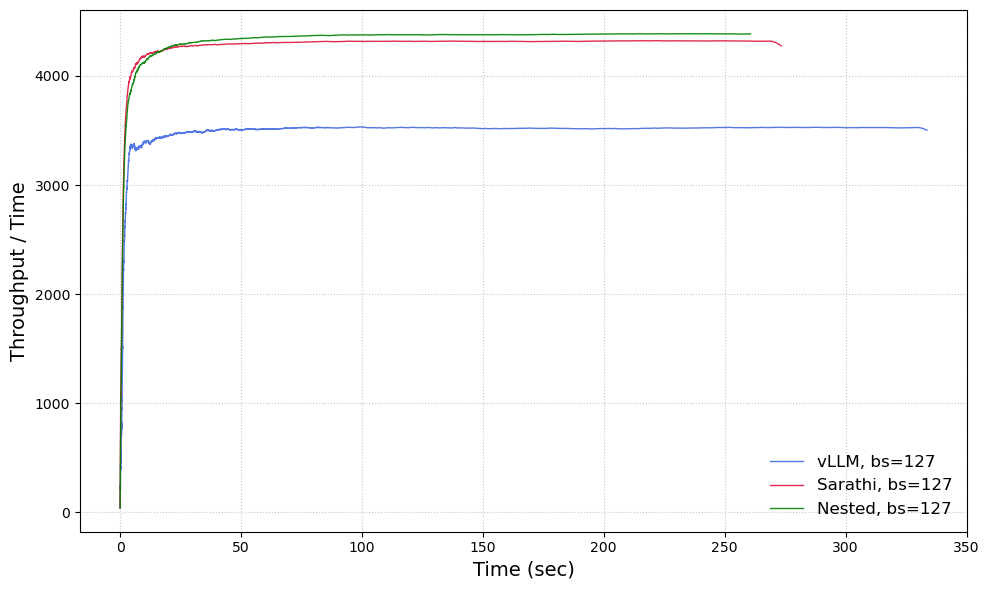

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
vllm_df = pd.read_csv('./vllm/throughput_vllm_batch_size_64.csv')
booking_df = pd.read_csv('./modified_nested/throughput_general_nested_booking_limit_limit_64_batch_size_62.csv')

# booking_df1 = pd.read_csv('./throughput_general_nested_booking_limit.csv')
sarathi_df = pd.read_csv("./sarathi/throughput_sarathi_batch_size_64.csv")

# 设置最大时间
T = 1700
vllm_subset = vllm_df[vllm_df['Time (sec)'] <= T].copy()
sarathi_subset = sarathi_df[sarathi_df['Time (sec)'] <= T].copy()
booking_subset = booking_df[booking_df['Time (sec)'] <= T].copy()
# booking_subset1 = booking_df1[booking_df1['Time (sec)'] <= T].copy()

# 计算 throughput / time
vllm_subset['throughput_per_time'] = vllm_subset['throughput'] / vllm_subset['Time (sec)']
sarathi_subset['throughput_per_time'] = sarathi_subset['throughput'] / sarathi_subset['Time (sec)']
booking_subset['throughput_per_time'] = booking_subset['throughput'] / booking_subset['Time (sec)']
# booking_subset1['throughput_per_time'] = booking_subset1['throughput'] / booking_subset1['Time (sec)']

# 画图
plt.figure(figsize=(10, 6))
plt.plot(vllm_subset['Time (sec)'], vllm_subset['throughput_per_time'], 
         color='royalblue', linestyle='-', linewidth=1, alpha=0.9, label='vLLM, bs=127')

plt.plot(sarathi_subset['Time (sec)'], sarathi_subset['throughput_per_time'], 
         color='crimson', linestyle='-', linewidth=1, alpha=0.9, label='Sarathi, bs=127')

plt.plot(booking_subset['Time (sec)'], booking_subset['throughput_per_time'], 
         color='green', linestyle='-', linewidth=1, alpha=0.9, label='Nested, bs=127')
# plt.plot(booking_subset1['Time (sec)'], booking_subset1['throughput_per_time'],
            # color='orange', linestyle='-', linewidth=1, alpha=0.9, label='Nested_new[90,20], bs=110')

# 设置标签和图例
plt.xlabel('Time (sec)', fontsize=14)
plt.ylabel('Throughput / Time', fontsize=14)
plt.legend(frameon=False, fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.ticklabel_format(axis='x', style='plain')  # 禁用科学计数法
plt.tight_layout()

# 显示图形
plt.show()

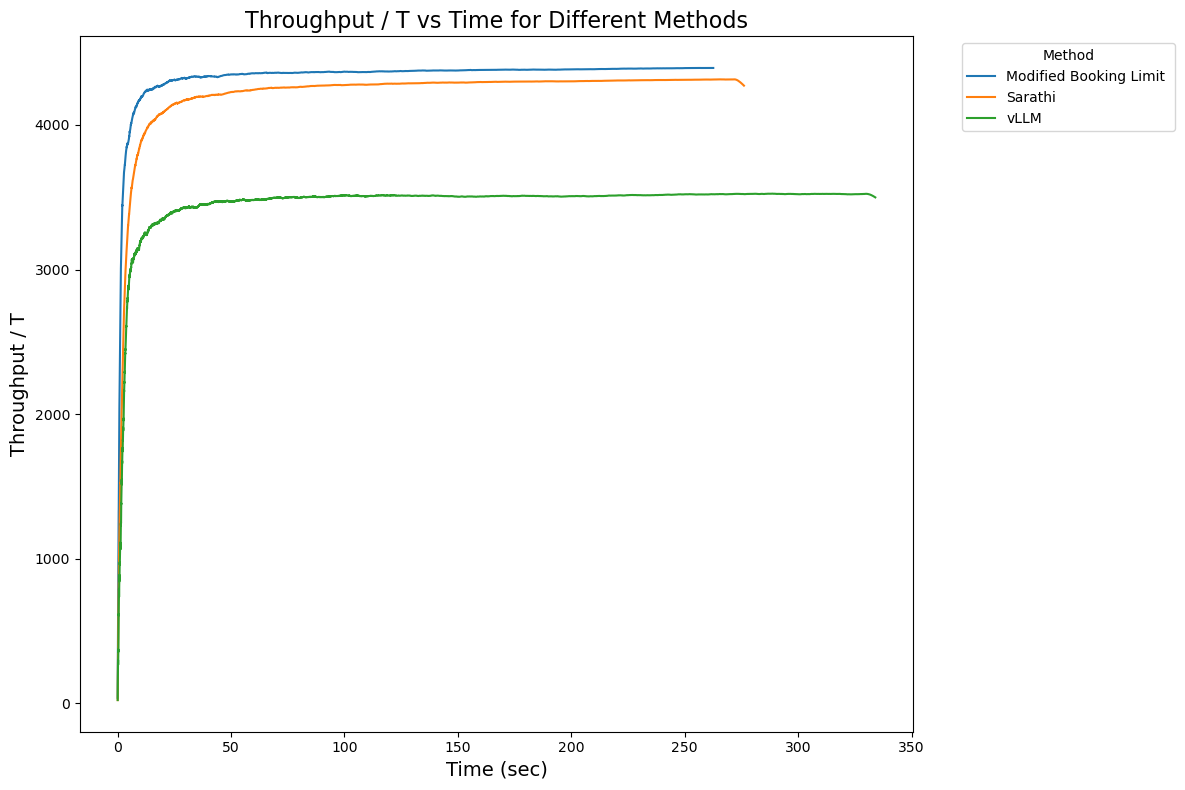

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 定义文件路径
file_paths = [
    "./DRAW/throughput_general_nested_booking_limit_limit_64, nested_real_qps=72_rates=_64_8_batch_size_62.csv",
    "./DRAW/throughput_sarathi_batch_size_64_qps=32, sarathi.csv",
    "./DRAW/throughput_vllm_batch_size_64, vllm.csv"
]

# 定义每条曲线的标签
labels = [
    'Modified Booking Limit ',
    'Sarathi',
    'vLLM'
]

# 创建一个新的图表
plt.figure(figsize=(12, 8))

# 遍历每个文件
for file_path, label in zip(file_paths, labels):
    # 使用pandas读取CSV文件
    df = pd.read_csv(file_path)
    
    # 计算 T时刻的throughput / T
    df['throughput_per_T'] = df['throughput'] / df['Time (sec)']
    
    # 绘制throughput_per_T随时间变化的曲线
    plt.plot(df['Time (sec)'], df['throughput_per_T'], label=label)

# 添加图例
plt.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')

# 添加标题和标签
plt.title('Throughput / T vs Time for Different Methods', fontsize=16)
plt.xlabel('Time (sec)', fontsize=14)
plt.ylabel('Throughput / T', fontsize=14)

# 调整布局，防止图例遮挡
plt.tight_layout()

# 显示图表
plt.show()

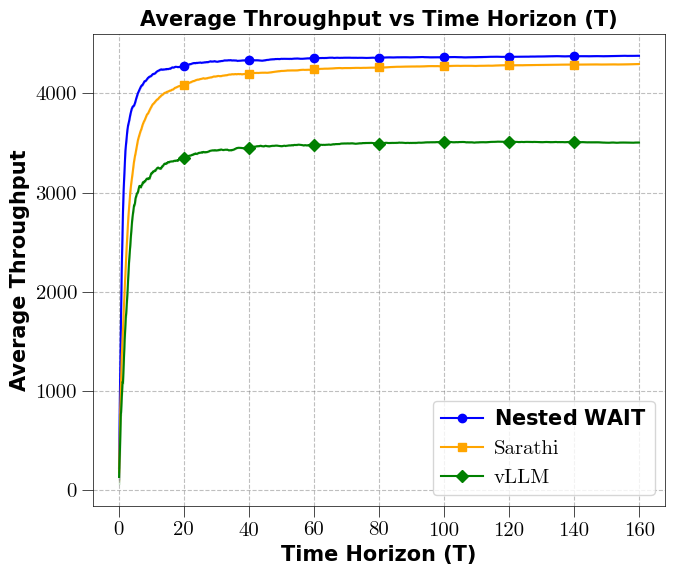

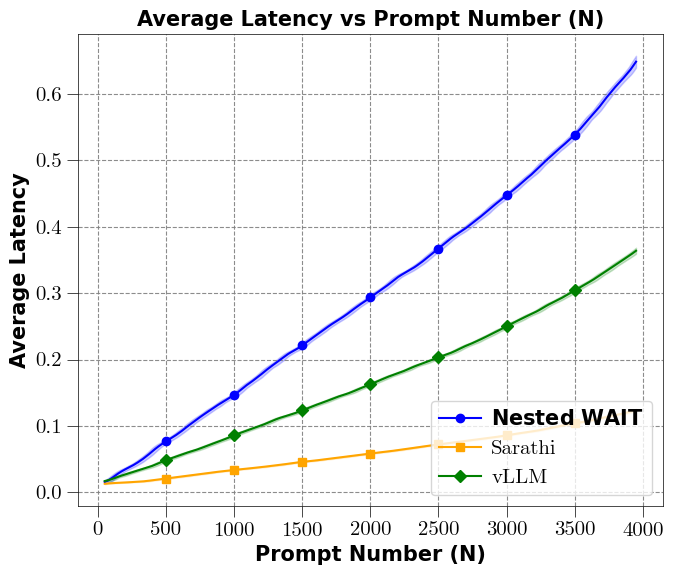

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np

add = "test36_simulated_short_decode_bs=64_nested_real_TRACE"

file_paths_throughput = [
    "./DRAW/throughput_general_nested_booking_limit_limit_64, nested_real_qps=72_rates=_64_8_batch_size_62.csv",
    "./DRAW/throughput_sarathi_batch_size_64_qps=32, sarathi.csv",
    "./DRAW/throughput_vllm_batch_size_64, vllm.csv"
]
labels_e2e = ['Nested WAIT', 'Sarathi', 'vLLM']
s = 160

e2e_file_paths = [
    "./DRAW/request_e2e_time_normalized_limit_64, nested_real_qps=72_rates=_64_8.csv",
    "./DRAW/request_e2e_time_normalized_batch_size_64_qps=32, sarathi.csv",
    "./DRAW/request_e2e_time_normalized_batch_size_64, vllm.csv"
]
a = 4000

# 设置 CMU Serif 字体
font_path = "/Users/luogan/Library/Fonts/CMU Serif Roman.ttf"
font_prop = fm.FontProperties(fname=font_path)

# 设置全局样式，但避免 Seaborn 覆盖刻度
plt.rcParams.update({
    'font.size': 15,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'figure.figsize': (8, 7)
})

# 绘制第一个图：Throughput / T vs Time
plt.figure(figsize=(7, 6))
markers = ['o', 's', 'D']  # 圆圈、正方形、菱形
colors = ['blue', 'orange', 'green']

# 设置x轴刻度
xticks = np.arange(0, s + 20, 20)

for file_path, label, marker, color in zip(file_paths_throughput, labels_e2e, markers, colors):
    df = pd.read_csv(file_path)
    df['throughput_per_T'] = df['throughput'] / df['Time (sec)']
    df_filtered = df[df['Time (sec)'] < s]
    
    window = 10
    rolling_mean = df_filtered['throughput_per_T'].rolling(window=window, center=True).mean()
    rolling_std = df_filtered['throughput_per_T'].rolling(window=window, center=True).std()
    
    plt.fill_between(df_filtered['Time (sec)'],
                     rolling_mean - rolling_std,
                     rolling_mean + rolling_std,
                     color=color, alpha=0.2)
    
    plt.plot(df_filtered['Time (sec)'], rolling_mean,
             color=color, label=label, linestyle='-')
    
    for tick in xticks:
        closest_idx = (df_filtered['Time (sec)'] - tick).abs().idxmin()
        plt.plot(df_filtered['Time (sec)'].iloc[closest_idx], 
                rolling_mean.iloc[closest_idx], 
                color=color, marker=marker, markersize=6)

plt.title('Average Throughput vs Time Horizon (T)', fontsize=15, weight='bold')
plt.xlabel('Time Horizon (T)', fontsize=15, weight='bold')
plt.ylabel('Average Throughput', fontsize=15, weight='bold')

handles, labels = plt.gca().get_legend_handles_labels()
new_handles = []
for handle, label, marker, color in zip(handles, labels, markers, colors):
    new_handle = plt.Line2D([], [], color=color, linestyle='-', marker=marker, markersize=6, label=label)
    new_handles.append(new_handle)

for i, label in enumerate(labels):
    if label == 'WAIT':
        labels[i] = r"$\bf{WAIT}$"
    if label == 'Nested WAIT':
        labels[i] = r"$\bf{Nested\ WAIT}$"

plt.legend(new_handles, labels, loc='lower right', prop=font_prop, scatterpoints=1, handletextpad=0.5)

plt.xticks(xticks, fontproperties=font_prop)
plt.yticks(fontproperties=font_prop)

# 设置网格线样式（手动添加，避免 Seaborn 干扰）
plt.grid(True, linestyle='--', alpha=0.5, color='gray')

# 设置边框
plt.gca().spines['top'].set_color('black')
plt.gca().spines['top'].set_linewidth(0.5)
plt.gca().spines['right'].set_color('black')
plt.gca().spines['right'].set_linewidth(0.5)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['bottom'].set_linewidth(0.5)
plt.gca().spines['left'].set_color('black')
plt.gca().spines['left'].set_linewidth(0.5)

# 设置刻度线向外延伸（放在最后，确保生效）
plt.tick_params(axis='both', which='major', direction='out', length=8, width=0.5)

plt.tight_layout()
plt.savefig(f"/Users/luogan/Code/vidur_or/PDF/{add}_throughput.pdf")
plt.show()

# 绘制第二个图：Normalized Request E2E Time vs Row Number
plt.figure(figsize=(7, 6))

xticks = np.arange(0, a + 500, 500)

for file_path, label, marker, color in zip(e2e_file_paths, labels_e2e, markers, colors):
    df_e2e = pd.read_csv(file_path)
    
    window = 100
    rolling_mean = df_e2e['request_e2e_time_normalized'][:a].rolling(window=window, center=True).mean()
    rolling_std = df_e2e['request_e2e_time_normalized'][:a].rolling(window=window, center=True).std()
    
    plt.fill_between(df_e2e.index[:a],
                     rolling_mean - rolling_std,
                     rolling_mean + rolling_std,
                     color=color, alpha=0.2)
    
    plt.plot(df_e2e.index[:a], rolling_mean,
             color=color, label=label, linestyle='-')
    
    for tick in xticks:
        if tick < a:
            closest_idx = min(tick, len(df_e2e.index[:a]) - 1)
            plt.plot(df_e2e.index[int(closest_idx)], 
                    rolling_mean.iloc[int(closest_idx)], 
                    color=color, marker=marker, markersize=6)

plt.title('Average Latency vs Prompt Number (N)', fontsize=15, weight='bold')
plt.xlabel('Prompt Number (N)', fontsize=15, weight='bold')
plt.ylabel('Average Latency', fontsize=15, weight='bold')

handles, labels = plt.gca().get_legend_handles_labels()
new_handles = []
for handle, label, marker, color in zip(handles, labels, markers, colors):
    new_handle = plt.Line2D([], [], color=color, linestyle='-', marker=marker, markersize=6, label=label)
    new_handles.append(new_handle)

for i, label in enumerate(labels):
    if label == 'WAIT':
        labels[i] = r"$\bf{WAIT}$"
    if label == 'Nested WAIT':
        labels[i] = r"$\bf{Nested\ WAIT}$"

plt.legend(new_handles, labels, loc='lower right', prop=font_prop, scatterpoints=1, handletextpad=0.5)

plt.xticks(xticks, fontproperties=font_prop)
plt.yticks(fontproperties=font_prop)

# 设置网格线样式
plt.grid(True, linestyle='--', alpha=0.9, color='gray')

plt.gca().spines['top'].set_color('black')
plt.gca().spines['top'].set_linewidth(0.5)
plt.gca().spines['right'].set_color('black')
plt.gca().spines['right'].set_linewidth(0.5)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['bottom'].set_linewidth(0.5)
plt.gca().spines['left'].set_color('black')
plt.gca().spines['left'].set_linewidth(0.5)

# 设置刻度线向外延伸（放在最后，确保生效）
plt.tick_params(axis='both', which='major', direction='out', length=8, width=0.5)

plt.tight_layout()
plt.savefig(f"/Users/luogan/Code/vidur_or/PDF/{add}_latency.pdf")
plt.show()